# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: **[Myint Zaw Hein]**
* Student ID: **[2503086G]**



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another personâ€™s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
# Data handling, visualisation and model persistence
from pathlib import Path
import warnings
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# All machine-learning models are implemented with scikit-learn, as required.
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             balanced_accuracy_score, classification_report,
                             f1_score)
from sklearn.model_selection import RandomizedSearchCV, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42
TARGET = "NObeyesdad"


# 1. Business Understanding

## Problem and goal
A preventive-health service needs a quick screening tool that groups an adult into one of seven weight-status categories using physical measurements, eating habits and activity patterns. This is a **multiclass classification** problem. The solution should support early awareness; it is **not a medical diagnosis**.

## Success criteria
**Macro F1-score** is the primary metric because every class should receive equal importance and the metric penalises weak class-level precision or recall. Accuracy and balanced accuracy are supporting metrics. Logistic regression provides the simpler baseline against which the tree models are compared.

## Assumptions and limitations
- Inputs use the same definitions and units as the training data.
- The data represents people from Mexico, Peru and Colombia, so other populations require validation.
- The [UCI source](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition) states that 77% of records were generated with Weka/SMOTE and 23% were collected directly. The tutor approved this dataset.
- High performance must therefore be validated on new, directly collected data before real-world use.

# 2. Data Understanding
The dataset contains demographic, physical, eating-habit and activity variables. `NObeyesdad` is the seven-class target.

## 2.1 Load dataset

In [5]:
# A relative path keeps the submitted project portable.
FILE_PATH = Path("obesity.csv")
if not FILE_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {FILE_PATH.resolve()}")
df = pd.read_csv(FILE_PATH)
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


NameError: name 'Path' is not defined

## 2.2 Summary Statistics

In [3]:
# Review data types and cardinality to plan preprocessing.
pd.DataFrame({"dtype": df.dtypes.astype(str), "unique_values": df.nunique()})


,dtype,unique_values
Gender,object,2
Age,float64,1402
Height,float64,1574
Weight,float64,1525
family_history_with_overweight,object,2
FAVC,object,2
FCVC,float64,810
NCP,float64,635
CAEC,object,4
SMOKE,object,2


In [4]:
# Missing values and exact duplicates are potential data-quality issues.
quality = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
})
print(f"Exact duplicate rows: {df.duplicated().sum()}")
quality


Exact duplicate rows: 24


,missing_count,missing_percent
Gender,0,0.0
Age,0,0.0
Height,0,0.0
Weight,0,0.0
family_history_with_overweight,0,0.0
FAVC,0,0.0
FCVC,0,0.0
NCP,0,0.0
CAEC,0,0.0
SMOKE,0,0.0


In [5]:
# Numerical ranges and categorical frequencies reveal outliers and rare groups.
display(df.describe().T.round(3))
for column in df.select_dtypes(include="object").columns:
    print(f"\n{column}: {df[column].value_counts().to_dict()}")


,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.313,6.346,14.00,19.947,22.778,26.000,61.00
Height,2111.0,1.702,0.093,1.45,1.630,1.700,1.768,1.98
Weight,2111.0,86.586,26.191,39.00,65.473,83.000,107.431,173.00
FCVC,2111.0,2.419,0.534,1.00,2.000,2.386,3.000,3.00
NCP,2111.0,2.686,0.778,1.00,2.659,3.000,3.000,4.00
CH2O,2111.0,2.008,0.613,1.00,1.585,2.000,2.477,3.00
FAF,2111.0,1.010,0.851,0.00,0.125,1.000,1.667,3.00
TUE,2111.0,0.658,0.609,0.00,0.000,0.625,1.000,2.00



Gender: {'Male': 1068, 'Female': 1043}

family_history_with_overweight: {'yes': 1726, 'no': 385}

FAVC: {'yes': 1866, 'no': 245}

CAEC: {'Sometimes': 1765, 'Frequently': 242, 'Always': 53, 'no': 51}

SMOKE: {'no': 2067, 'yes': 44}

SCC: {'no': 2015, 'yes': 96}

CALC: {'Sometimes': 1401, 'no': 639, 'Frequently': 70, 'Always': 1}

MTRANS: {'Public_Transportation': 1580, 'Automobile': 457, 'Walking': 56, 'Motorbike': 11, 'Bike': 7}

NObeyesdad: {'Obesity_Type_I': 351, 'Obesity_Type_III': 324, 'Obesity_Type_II': 297, 'Overweight_Level_I': 290, 'Overweight_Level_II': 290, 'Normal_Weight': 287, 'Insufficient_Weight': 272}


## 2.3 Data Visualization
**Data-quality interpretation**

**Observation:** The dataset has no missing values in any feature, so the records are complete for modelling. There are 24 exact duplicate rows, and the variables contain both numerical measurements and categorical lifestyle responses.

**Business relevance:** In an obesity-screening context, complete records are important because missing height, weight, eating-habit, or activity values would reduce confidence in the prediction. Duplicate records can make model performance look better than it really is if the same profile appears in both training and testing data.

**Modelling implication:** No imputation is required. Exact duplicates should be removed before train-test splitting to reduce train-test contamination. Numerical and categorical inputs need separate preprocessing because numerical measurements can be scaled, while categorical responses must be encoded before they can be used by scikit-learn models.


### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

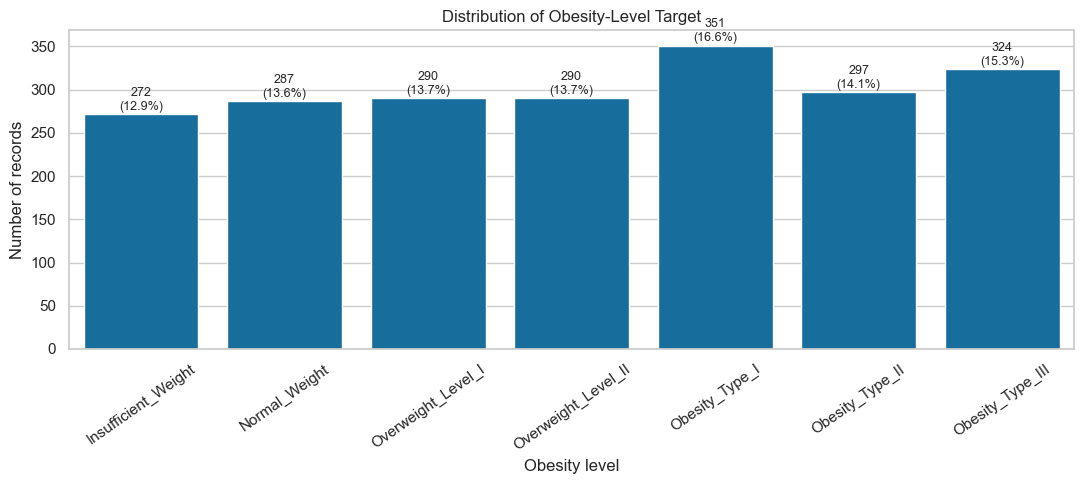

,count,percent
NObeyesdad,,
Insufficient_Weight,272,12.9
Normal_Weight,287,13.6
Overweight_Level_I,290,13.7
Overweight_Level_II,290,13.7
Obesity_Type_I,351,16.6
Obesity_Type_II,297,14.1
Obesity_Type_III,324,15.3


In [6]:
class_order = ["Insufficient_Weight", "Normal_Weight", "Overweight_Level_I",
               "Overweight_Level_II", "Obesity_Type_I", "Obesity_Type_II",
               "Obesity_Type_III"]
target_counts = df[TARGET].value_counts().reindex(class_order)
target_share = (target_counts / len(df) * 100).round(1)
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax)
ax.set(title="Distribution of Obesity-Level Target",
       xlabel="Obesity level", ylabel="Number of records")
ax.tick_params(axis="x", rotation=35)
for i, (count, share) in enumerate(zip(target_counts, target_share)):
    ax.text(i, count + 5, f"{count}\n({share}%)", ha="center", fontsize=9)
plt.tight_layout()
plt.show()
pd.DataFrame({"count": target_counts, "percent": target_share})


**Target-distribution interpretation**

**Observation:** The target classes are reasonably balanced, ranging from 272 records for `Insufficient_Weight` to 351 records for `Obesity_Type_I`. Each class contributes roughly 12.9% to 16.6% of the dataset.

**Business relevance:** The screening tool needs to recognise all seven obesity-level categories, not only the most common category. A reasonably balanced target distribution gives the model enough examples from each class to learn class-specific patterns.

**Modelling implication:** A stratified train-test split should be used so the train and test sets preserve similar class proportions. Accuracy can be reported, but macro F1-score is a better primary metric because it gives equal importance to every obesity class.


### 2.3.1.1a Understanding Distribution of Categorical Features
This section checks how common each categorical response is. It is useful for identifying rare lifestyle categories that may be less reliable for the model to learn.


In [ ]:
categorical_features_eda = [
    "Gender", "family_history_with_overweight", "FAVC", "CAEC",
    "SMOKE", "SCC", "CALC", "MTRANS"
]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for column, ax in zip(categorical_features_eda, axes.ravel()):
    order = df[column].value_counts().index
    sns.countplot(data=df, y=column, order=order, ax=ax)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel("Number of records")
    ax.set_ylabel(column)
plt.tight_layout()
plt.show()



**Categorical-feature interpretation**

**Observation:** Several categorical variables are highly uneven. `SMOKE` is mostly `no`, `SCC` is mostly `no`, `FAVC` is mostly `yes`, and `MTRANS` is mostly `Public_Transportation`. Some categories such as `Bike`, `Motorbike`, `Always` for `CALC`, and `yes` for `SMOKE` appear much less often than their alternatives.

**Business relevance:** These variables describe lifestyle behaviours related to eating, transport, smoking, and calorie monitoring. Rare categories are still meaningful, but they represent fewer real examples in the dataset, so any pattern learned from them may be less stable.

**Modelling implication:** The categorical features should be retained because they are relevant to obesity risk behaviour, but they must be converted into numeric indicators using one-hot encoding. `handle_unknown="ignore"` is appropriate because future user inputs may contain categories that were rare or unseen during training. Rare-category effects should be interpreted cautiously.


### 2.3.1.2 Understanding Distribution of Numerical Features
The numerical histograms show the range and shape of each measurement or survey-scale variable. This helps decide whether scaling or non-linear models are needed.


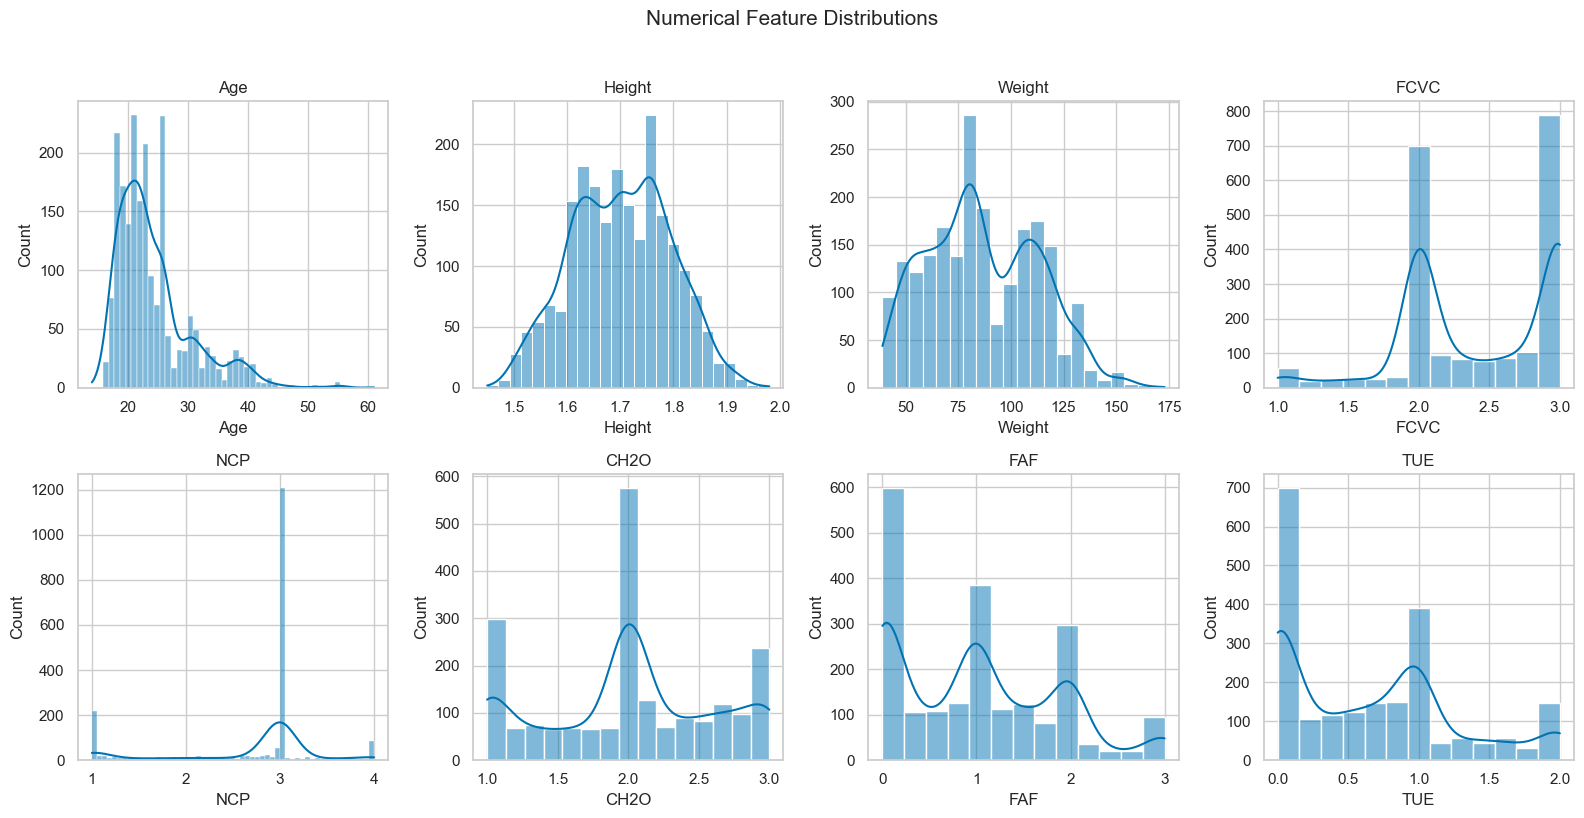

In [7]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for column, ax in zip(numeric_columns, axes.ravel()):
    sns.histplot(df[column], kde=True, ax=ax)
    ax.set_title(column)
for ax in axes.ravel()[len(numeric_columns):]:
    ax.remove()
fig.suptitle("Numerical Feature Distributions", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()


**Numerical-distribution interpretation**

**Observation:** `Age` and `Weight` are right-skewed, meaning most records are concentrated in lower or middle ranges while some records extend to higher values. Several questionnaire-style numerical variables such as `FCVC`, `NCP`, `CH2O`, `FAF`, and `TUE` cluster around survey scale values instead of following a normal bell-shaped distribution.

**Business relevance:** This is expected for an obesity dataset because body measurements and lifestyle habits vary across people. Higher weight and older age profiles are relevant to screening and should not be treated as errors just because they are less common.

**Modelling implication:** Scaling is useful for logistic regression because numerical features have different ranges. Tree-based models such as decision trees and random forests are also appropriate because they can learn threshold-based and non-linear relationships without requiring normally distributed inputs.


### 2.3.1.3 Outlier Analysis
Boxplots and IQR counts are used to identify unusual numerical values. The purpose is to judge whether values are impossible errors or plausible obesity-screening profiles.


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for column, ax in zip(numeric_columns, axes.ravel()):
    sns.boxplot(data=df, y=column, ax=ax)
    ax.set_title(f"Outlier Check: {column}")
    ax.set_ylabel(column)
for ax in axes.ravel()[len(numeric_columns):]:
    ax.remove()
plt.tight_layout()
plt.show()

outlier_summary = []
for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    outlier_summary.append({
        "feature": column,
        "lower_bound": round(lower_bound, 2),
        "upper_bound": round(upper_bound, 2),
        "outlier_count": outlier_count,
        "minimum": round(df[column].min(), 2),
        "maximum": round(df[column].max(), 2),
    })
pd.DataFrame(outlier_summary)



**Outlier interpretation**

**Observation:** `Age` has the clearest IQR-based outliers, with some older records compared with the main age range. `Height` and `Weight` have very few IQR-based outliers, and the observed minimum and maximum values remain plausible for human measurements in this dataset. `NCP` also shows many IQR-based outliers because it is concentrated around common meal-frequency survey values, not because the values are necessarily invalid.

**Business relevance:** For obesity prediction, unusual but realistic ages, weights, and eating-pattern responses may represent important user profiles. Removing them automatically could make the screening tool less useful for people outside the most common range.

**Modelling implication:** The project should keep these records instead of applying aggressive outlier removal. Numerical scaling supports logistic regression, while tree-based models are useful because they can handle non-linear cut-off points and are less sensitive to skewed feature distributions.


### 2.3.2 Understanding Relationships Between Variables
This section compares key predictors with the obesity-level target and checks relationships among numerical variables. The aim is to identify features that are meaningful for prediction, not to claim medical causation.


In [ ]:
# BMI exposes the interaction between height and weight.
eda_df = df.copy()
eda_df["BMI"] = eda_df["Weight"] / eda_df["Height"].pow(2)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=eda_df, x=TARGET, y="BMI", order=class_order, ax=axes[0])
axes[0].set(title="BMI by Target Class", xlabel="Obesity level", ylabel="BMI (kg/m^2)")
axes[0].tick_params(axis="x", rotation=40)
family_table = pd.crosstab(eda_df["family_history_with_overweight"],
                           eda_df[TARGET], normalize="index").reindex(columns=class_order)
family_table.T.plot(kind="bar", ax=axes[1])
axes[1].set(title="Target Mix by Family History", xlabel="Obesity level",
            ylabel="Proportion within group")
axes[1].tick_params(axis="x", rotation=40)
axes[1].legend(title="Family history")
plt.tight_layout()
plt.show()
display(eda_df.groupby(TARGET)["BMI"].agg(["mean", "median", "min", "max"])
        .reindex(class_order).round(2))
plt.figure(figsize=(9, 7))
sns.heatmap(eda_df.select_dtypes(include=np.number).corr(), annot=True,
            fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Between Numerical Variables")
plt.tight_layout()
plt.show()


**Relationship and correlation interpretation**

**Observation:** BMI increases clearly across the ordered obesity-level classes, from lower BMI values in `Insufficient_Weight` and `Normal_Weight` to higher BMI values in the obesity classes. The correlation heatmap also shows that `Weight` and engineered `BMI` are strongly related, while most other numerical variables have weaker linear relationships. The family-history chart shows that records with family history of overweight have a higher share of obesity classes than records without family history.

**Business relevance:** BMI is a direct summary of the relationship between height and weight, which is central to an obesity-level screening problem. Family history is also relevant because it may reflect genetic, household, or long-term lifestyle factors associated with weight status. However, these patterns should be treated as predictive associations, not proof of medical causation.

**Modelling implication:** BMI should be added as a meaningful engineered feature because it captures the height-weight interaction more directly than the original two columns alone. Since BMI and weight are highly related, feature importance should be interpreted carefully. Random forest is suitable because it can combine BMI, family history, eating behaviour, and activity variables without assuming purely linear relationships.


### 2.3.2.1 Target Versus High-Calorie Food Consumption
`FAVC` is examined as an additional target-versus-categorical feature because frequent high-calorie food consumption is a direct eating-habit factor in the obesity prediction problem.


In [ ]:
favc_table = pd.crosstab(
    df["FAVC"], df[TARGET], normalize="index"
).reindex(columns=class_order)

favc_table.T.plot(kind="bar", figsize=(12, 5))
plt.title("Target Mix by Frequent High-Calorie Food Consumption")
plt.xlabel("Obesity level")
plt.ylabel("Proportion within FAVC group")
plt.xticks(rotation=35, ha="right")
plt.legend(title="FAVC")
plt.tight_layout()
plt.show()
display((favc_table * 100).round(1))



**Target-versus-categorical interpretation**

**Observation:** Records with `FAVC = yes` contain higher proportions of obesity classes than records with `FAVC = no`. Records with `FAVC = no` show larger proportions in `Normal_Weight` and `Overweight_Level_II` compared with several obesity classes.

**Business relevance:** Frequent high-calorie food consumption is a behaviour that can contribute to weight gain over time, so it is a relevant lifestyle signal for an obesity-level screening model. The pattern also supports including eating-habit variables rather than relying only on physical measurements.

**Modelling implication:** `FAVC` should be kept as a categorical predictor and one-hot encoded. It may help the model distinguish normal, overweight, and obesity groups when combined with BMI, family history, activity, and other eating-habit features.


# 3. Data Preparation
**EDA summary and modelling implications**

**Observation:** The EDA shows that the dataset is complete, the target classes are reasonably balanced, numerical variables have different ranges and skewed shapes, and several categorical lifestyle responses are unevenly distributed. BMI rises consistently across the obesity-level categories, family history changes the target mix, and frequent high-calorie food consumption shows a visible relationship with higher obesity classes.

**Business relevance:** These findings match the problem context because obesity level is influenced by physical measurements, eating habits, activity patterns, and lifestyle background. The analysis also shows that the model should support all seven target classes rather than focusing only on the largest class.

**Modelling implication:** Exact duplicates will be removed before splitting to reduce leakage risk. BMI will be added as a meaningful engineered feature because it captures the height-weight relationship. Numerical features will be scaled for logistic regression, categorical features will be one-hot encoded, stratified splitting will preserve class proportions, and both linear and tree-based models will be compared because the EDA suggests a mix of linear, non-linear, and categorical patterns.


## 3.1 Data Cleaning

In [9]:
# Remove exact duplicates before splitting to reduce train-test contamination.
model_df = df.drop_duplicates().copy()
if (model_df["Height"] <= 0).any():
    raise ValueError("Height must be positive before BMI is calculated.")

# BMI is a meaningful interaction available from two user inputs.
model_df["BMI"] = model_df["Weight"] / model_df["Height"].pow(2)
print(f"Rows before cleaning: {len(df):,}")
print(f"Duplicate rows removed: {len(df) - len(model_df):,}")
print(f"Rows after cleaning: {len(model_df):,}")
model_df[["Height", "Weight", "BMI", TARGET]].head()


Rows before cleaning: 2,111
Duplicate rows removed: 24
Rows after cleaning: 2,087


,Height,Weight,BMI,NObeyesdad
0,1.62,64.0,24.386526,Normal_Weight
1,1.52,56.0,24.238227,Normal_Weight
2,1.80,77.0,23.765432,Normal_Weight
3,1.80,87.0,26.851852,Overweight_Level_I
4,1.78,89.8,28.342381,Overweight_Level_II


## 3.2 Train-Test Split and Preprocessing
A stratified 80:20 split preserves class proportions. All learned preprocessing is inside each pipeline, preventing validation and test information from leaking into training.

In [10]:
X = model_df.drop(columns=TARGET)
y = model_df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()
preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
     categorical_features),
])
print(f"Training rows: {len(X_train):,}; test rows: {len(X_test):,}")
print(f"Numerical features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
pd.DataFrame({
    "train_percent": (y_train.value_counts(normalize=True) * 100).round(1),
    "test_percent": (y_test.value_counts(normalize=True) * 100).round(1),
}).reindex(class_order)


Training rows: 1,669; test rows: 418
Numerical features (9): ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']
Categorical features (8): ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


,train_percent,test_percent
NObeyesdad,,
Insufficient_Weight,12.8,12.7
Normal_Weight,13.5,13.6
Overweight_Level_I,13.2,13.2
Overweight_Level_II,13.9,13.9
Obesity_Type_I,16.8,16.7
Obesity_Type_II,14.2,14.4
Obesity_Type_III,15.5,15.6


# 4. Modelling
Three learned algorithms are compared: multinomial logistic regression as the baseline, a decision tree for interpretable non-linear rules, and random forest for more stable non-linear thresholds and interactions. Five-fold cross-validation on the training set provides a stable comparison.

## 4.1 Train and Compare Candidate Models

In [11]:
models = {
    "Logistic regression": LogisticRegression(
        max_iter=2500, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision tree": DecisionTreeClassifier(
        max_depth=12, class_weight="balanced", random_state=RANDOM_STATE),
    "Random forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced_subsample",
        random_state=RANDOM_STATE, n_jobs=-1),
}
scoring = {"macro_f1": "f1_macro", "accuracy": "accuracy",
           "balanced_accuracy": "balanced_accuracy"}
results = []
fitted_models = {}
for name, estimator in models.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    scores = cross_validate(pipeline, X_train, y_train, cv=5,
                            scoring=scoring, n_jobs=-1)
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    predictions = pipeline.predict(X_test)
    results.append({
        "model": name,
        "cv_macro_f1_mean": scores["test_macro_f1"].mean(),
        "cv_macro_f1_std": scores["test_macro_f1"].std(),
        "test_macro_f1": f1_score(y_test, predictions, average="macro"),
        "test_accuracy": accuracy_score(y_test, predictions),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, predictions),
    })
comparison = (pd.DataFrame(results).set_index("model")
              .sort_values("cv_macro_f1_mean", ascending=False))
comparison.round(4)


,cv_macro_f1_mean,cv_macro_f1_std,test_macro_f1,test_accuracy,test_balanced_accuracy
model,,,,,
Random forest,0.9781,0.0144,0.9778,0.9785,0.9780
Decision tree,0.9670,0.0096,0.9627,0.9641,0.9624
Logistic regression,0.9013,0.0172,0.9226,0.9258,0.9241


# 5. Model Evaluation
## 5.1 Baseline and Candidate Comparison
Logistic regression provides the simpler learned baseline. The decision tree tests whether one tree can capture useful non-linear rules, while random forest reduces the variance of a single tree by averaging many trees. Random forest is selected for refinement when it has the strongest cross-validated macro F1. Selection is based primarily on cross-validation rather than the held-out test score.

,cv_macro_f1_mean,cv_macro_f1_std,test_macro_f1,test_accuracy,test_balanced_accuracy
model,,,,,
Random forest,0.9781,0.0144,0.9778,0.9785,0.9780
Decision tree,0.9670,0.0096,0.9627,0.9641,0.9624
Logistic regression,0.9013,0.0172,0.9226,0.9258,0.9241


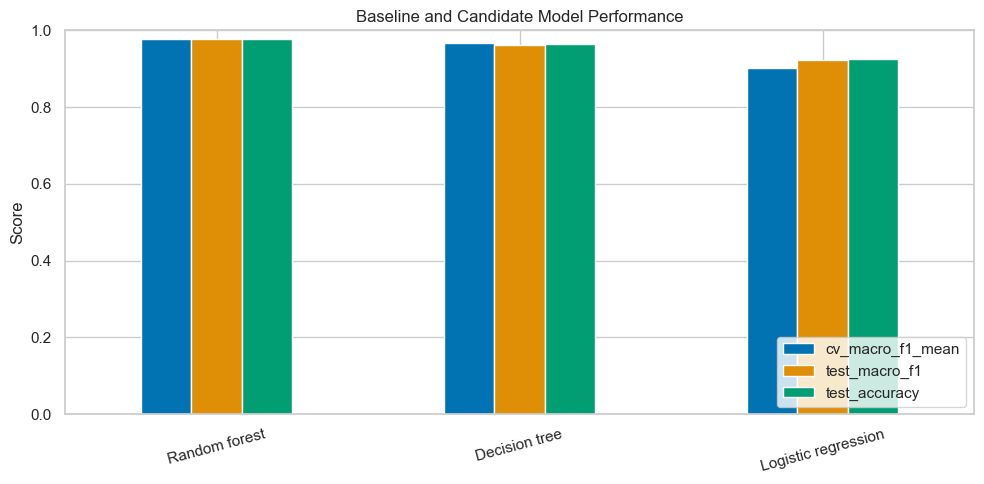

In [12]:
display(comparison.round(4))
comparison[["cv_macro_f1_mean", "test_macro_f1", "test_accuracy"]].plot(
    kind="bar", figsize=(10, 5), ylim=(0, 1), rot=15)
plt.title("Baseline and Candidate Model Performance")
plt.ylabel("Score")
plt.xlabel("")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [13]:
# Quantify the improvement over a no-skill baseline.
best_candidate = comparison.index[0]
improvement = (comparison.loc[best_candidate, "cv_macro_f1_mean"] -
               comparison.loc["Logistic regression", "cv_macro_f1_mean"])
print(f"Strongest candidate by CV macro F1: {best_candidate}")
print(f"Absolute CV macro-F1 improvement over logistic baseline: {improvement:.4f}")


Strongest candidate by CV macro F1: Random forest
Absolute CV macro-F1 improvement over logistic baseline: 0.0768


## 5.2 Iterative Development and Hyperparameter Tuning
`RandomizedSearchCV` is used as required. Five random-forest hyperparameters are varied, with no more than three values each. Fifteen sampled combinations are compared with five-fold cross-validation and macro F1.

| Iteration | Change | Evidence / reason | Decision |
|---|---|---|---|
| 1 | Logistic regression baseline | Tests a simpler linear multiclass solution | Interpretable baseline |
| 2 | Decision tree | Tests one interpretable set of non-linear rules | Compare stability and performance |
| 3 | Random forest | Averages many trees to reduce variance | Refine if CV macro F1 is strongest |
| 4 | Remove duplicates and add BMI | Reduces leakage risk and exposes the height-weight interaction | Retain |
| 5 | Randomized hyperparameter search | Tests model capacity and regularisation reproducibly | Select highest CV macro F1 |

In [14]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)),
])
# No hyperparameter has more than three candidate values.
parameter_distributions = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [None, 12, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.7, None],
}
search = RandomizedSearchCV(
    rf_pipeline, parameter_distributions, n_iter=15, scoring="f1_macro",
    cv=5, random_state=RANDOM_STATE, n_jobs=-1,
    return_train_score=True, verbose=1)
search.fit(X_train, y_train)
print(f"Best cross-validated macro F1: {search.best_score_:.4f}")
print("Best parameters:")
for parameter, value in search.best_params_.items():
    print(f"  {parameter}: {value}")

tuning_results = pd.DataFrame(search.cv_results_)
tuning_columns = ["rank_test_score", "mean_test_score", "std_test_score",
                  "mean_train_score", "param_model__n_estimators",
                  "param_model__max_depth", "param_model__min_samples_split",
                  "param_model__min_samples_leaf", "param_model__max_features"]
tuning_results[tuning_columns].sort_values("rank_test_score").head(10).round(4)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best cross-validated macro F1: 0.9806
Best parameters:
  model__n_estimators: 400
  model__min_samples_split: 2
  model__min_samples_leaf: 1
  model__max_features: sqrt
  model__max_depth: 12


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features
14,1,0.9806,0.0150,1.0000,400,12,2,1,sqrt
8,2,0.9800,0.0152,0.9992,200,None,2,2,sqrt
1,3,0.9799,0.0141,0.9984,200,None,10,1,sqrt
5,4,0.9788,0.0146,0.9988,400,20,5,2,sqrt
13,5,0.9782,0.0140,0.9984,600,20,10,1,sqrt
9,6,0.9780,0.0054,0.9994,600,12,5,1,0.7
0,7,0.9748,0.0154,0.9965,200,None,10,4,sqrt
12,8,0.9733,0.0070,0.9940,600,20,2,2,None
6,9,0.9703,0.0052,0.9843,600,20,10,4,0.7
11,10,0.9703,0.0038,0.9866,600,20,2,4,0.7


,Tuned random forest
Macro F1,0.9829
Accuracy,0.9833
Balanced accuracy,0.9830


,precision,recall,f1-score,support
Insufficient_Weight,1.000,1.000,1.000,53.000
Normal_Weight,0.934,1.000,0.966,57.000
Overweight_Level_I,1.000,0.945,0.972,55.000
Overweight_Level_II,0.966,0.966,0.966,58.000
Obesity_Type_I,1.000,0.986,0.993,70.000
Obesity_Type_II,0.984,1.000,0.992,60.000
Obesity_Type_III,1.000,0.985,0.992,65.000
accuracy,0.983,0.983,0.983,0.983
macro avg,0.983,0.983,0.983,418.000
weighted avg,0.984,0.983,0.983,418.000


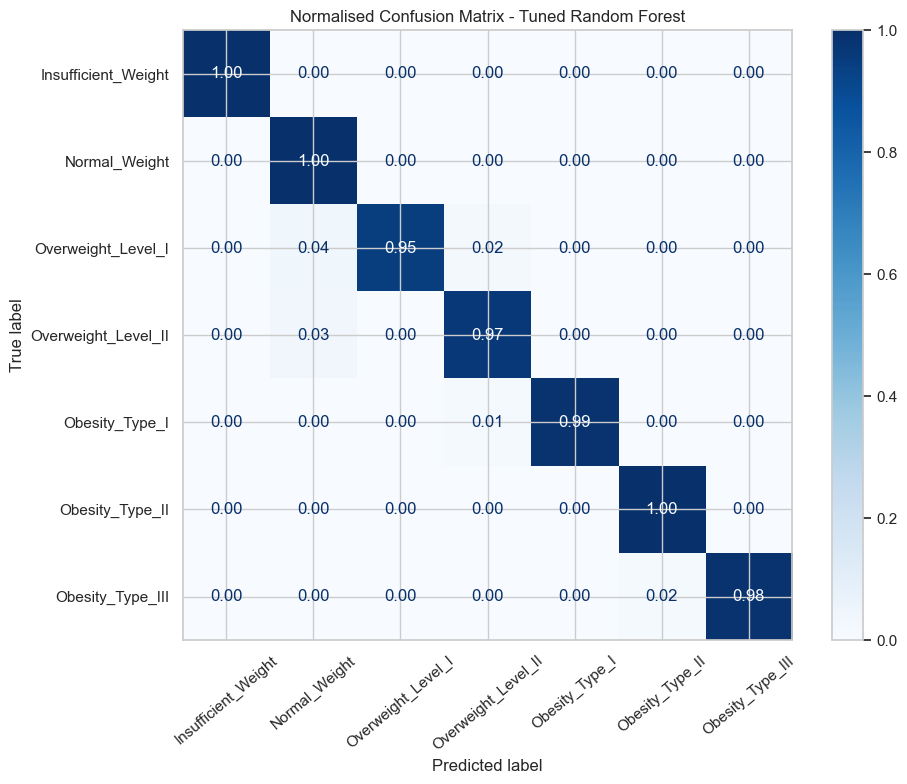

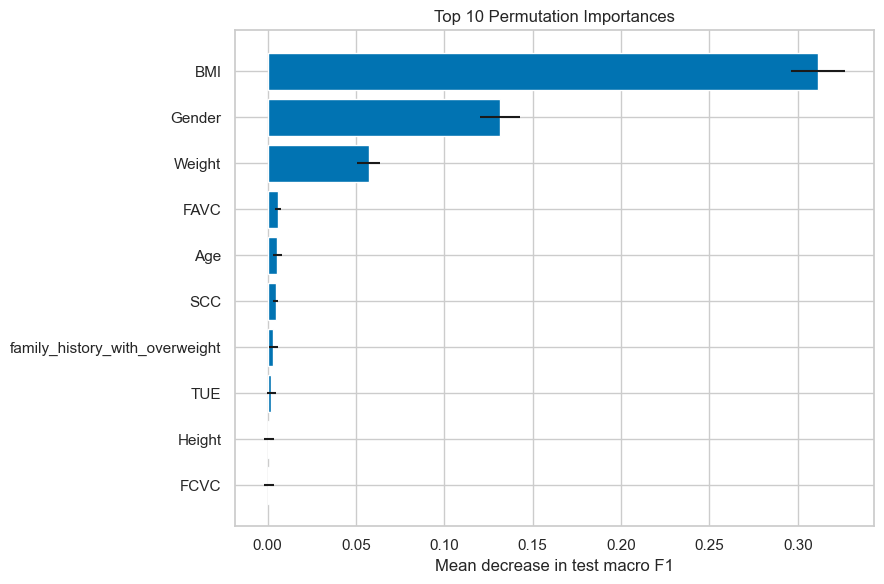

,feature,importance_mean,importance_std
16,BMI,0.3115,0.0152
0,Gender,0.1318,0.0113
3,Weight,0.0571,0.0065
5,FAVC,0.0059,0.0016
1,Age,0.0055,0.0024
11,SCC,0.0046,0.0015
4,family_history_with_overweight,0.0033,0.0024
13,TUE,0.0020,0.0025
2,Height,0.0010,0.0029
6,FCVC,0.0006,0.0029


Predicted class: Overweight_Level_II
Actual class:    Overweight_Level_II


,predicted_probability
Overweight_Level_II,0.9077
Overweight_Level_I,0.0443
Normal_Weight,0.0291
Obesity_Type_I,0.0081
Insufficient_Weight,0.0054
Obesity_Type_III,0.0051
Obesity_Type_II,0.0002


Saved deployable pipeline to: D:\Machine_Learning\Project\MLDP_project\obesity_model.joblib

Business interpretation:
- Compare macro F1 with the logistic-regression baseline.
- Adjacent-class errors are more plausible than errors between extremes.
- Feature importance is predictive association, not causation.
- External validation on directly collected data is the next required step.


In [15]:
## Final held-out evaluation
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
final_metrics = pd.Series({
    "Macro F1": f1_score(y_test, y_pred, average="macro"),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced accuracy": balanced_accuracy_score(y_test, y_pred),
}, name="Tuned random forest")
display(final_metrics.to_frame().round(4))
display(pd.DataFrame(classification_report(
    y_test, y_pred, labels=class_order, output_dict=True, zero_division=0)).T.round(3))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=class_order, normalize="true", cmap="Blues",
    xticks_rotation=40, values_format=".2f", ax=ax)
ax.set_title("Normalised Confusion Matrix - Tuned Random Forest")
plt.tight_layout()
plt.show()

## Model interpretation at the original user-input level
importance = permutation_importance(
    best_model, X_test, y_test, scoring="f1_macro", n_repeats=10,
    random_state=RANDOM_STATE, n_jobs=-1)
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std,
}).sort_values("importance_mean", ascending=False)
top_importance = importance_df.head(10).sort_values("importance_mean")
plt.figure(figsize=(9, 6))
plt.barh(top_importance["feature"], top_importance["importance_mean"],
         xerr=top_importance["importance_std"])
plt.title("Top 10 Permutation Importances")
plt.xlabel("Mean decrease in test macro F1")
plt.tight_layout()
plt.show()
display(importance_df.head(10).round(4))

## Example prediction and deployment export
new_data = X_test.iloc[[0]].copy()
predicted_class = best_model.predict(new_data)[0]
probabilities = pd.Series(
    best_model.predict_proba(new_data)[0],
    index=best_model.named_steps["model"].classes_).sort_values(ascending=False)
print(f"Predicted class: {predicted_class}")
print(f"Actual class:    {y_test.loc[new_data.index[0]]}")
display(probabilities.rename("predicted_probability").to_frame().round(4))
MODEL_PATH = Path("obesity_model.joblib")
joblib.dump(best_model, MODEL_PATH)
print(f"Saved deployable pipeline to: {MODEL_PATH.resolve()}")

print("\nBusiness interpretation:")
print("- Compare macro F1 with the logistic-regression baseline.")
print("- Adjacent-class errors are more plausible than errors between extremes.")
print("- Feature importance is predictive association, not causation.")
print("- External validation on directly collected data is the next required step.")


# 6. Conclusion and Next Steps
The completed pipeline combines duplicate removal, BMI feature engineering, mixed-type preprocessing and seven-class prediction in one deployable object. Model choice is supported by three learned algorithms, cross-validation, held-out testing and documented hyperparameter tuning.

**Next steps:** validate on newly collected non-synthetic data, examine fairness across demographic groups, add Streamlit input validation and user-facing error messages, monitor input drift, and obtain clinical/privacy review before use beyond an educational screening demonstration.

**Dataset reference:** Palechor, F. M., & de la Hoz Manotas, A. (2019). *Estimation of obesity levels based on eating habits and physical condition* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5H31Z